In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.4 MB/s eta 0:00:00


In [ ]:
!pip install kaggle

In [ ]:
import os
import json

kaggle_username = "akhi1205"
kaggle_key = "KGAT_0527bc3897e94be0ec5482501d763c71"

kaggle_json = {
    "username": kaggle_username,
    "key": kaggle_key
}

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_json, f)

os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle API configured successfully!")

Kaggle API configured successfully!


In [ ]:
!kaggle datasets list

ref                                                                  title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
amar5693/screen-time-sleep-and-stress-analysis-dataset               Screen Time, Sleep & Stress Analysis Dataset            787136  2026-02-13 06:56:18.757000           4249         83  1.0              
amar5693/student-performance-dataset                                 Student Performance Dataset                             177286  2026-02-12 06:04:44.613000           3827         62  1.0              
aliiihussain/amazon-sales-dataset                                    Amazon_Sales_Dataset                                   1297759  2026-02-01 11:37:12.353000           7404      

In [ ]:
!kaggle datasets download -d ggrill/foodseg103

Dataset URL: https://www.kaggle.com/datasets/ggrill/foodseg103
License(s): apache-2.0
 99% 1.16G/1.17G [00:13<00:00, 318MB/s]
100% 1.17G/1.17G [00:13<00:00, 95.7MB/s]


In [ ]:
import zipfile

with zipfile.ZipFile("foodseg103.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/foodseg103")

print("Dataset extracted!")

Dataset extracted!


In [ ]:
import os

os.listdir("/content")

['.config', 'foodseg103', 'foodseg103.zip', 'sample_data']

In [ ]:
import os
os.listdir("/content/foodseg103/FoodSeg103")

['train_test_recipe1m_id.txt',
 'test_recipe1m_id.txt',
 'Readme.txt',
 'category_id.txt',
 'Images',
 'ImageSets']

In [ ]:
import os
os.listdir("/content/foodseg103/FoodSeg103/Images")

['img_dir', 'ann_dir']

In [ ]:
os.listdir("/content/foodseg103/FoodSeg103/ImageSets")

['train.txt', 'test.txt']

In [ ]:
base_path = "/content/foodseg103/FoodSeg103"

image_dir = f"{base_path}/Images/img_dir"
mask_dir = f"{base_path}/Images/ann_dir"

train_txt = f"{base_path}/ImageSets/train.txt"
val_txt   = f"{base_path}/ImageSets/test.txt"

In [ ]:
def load_ids(txt_path):
    with open(txt_path, "r") as f:
        ids = f.read().splitlines()
    return ids

train_ids = load_ids(train_txt)
val_ids   = load_ids(val_txt)

print("Train samples:", len(train_ids))
print("Validation samples:", len(val_ids))

Train samples: 4983
Validation samples: 2135


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil

shutil.copy(
    "/content/foodseg103/FoodSeg103/category_id.txt",
    "/content/drive/MyDrive/category_id.txt"
)

print("Category file saved to Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Category file saved to Drive.


In [ ]:
import cv2
import torch
import os

class FoodSegDataset(Dataset):
    def __init__(self, ids, image_dir, mask_dir, split):
        self.ids = ids
        self.image_dir = os.path.join(image_dir, split)
        self.mask_dir = os.path.join(mask_dir, split)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_name = self.ids[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_name = img_name.replace(".jpg", ".png")
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, 0)

        # 🔥 RESIZE BOTH
        image = cv2.resize(image, (256, 256))
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)

        image = image / 255.0

        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)
        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask

In [ ]:
train_dataset = FoodSegDataset(train_ids, image_dir, mask_dir, split="train")
val_dataset   = FoodSegDataset(val_ids, image_dir, mask_dir, split="test")

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)

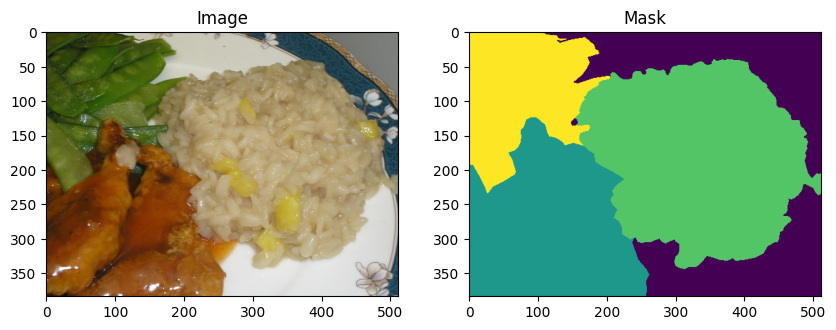

Unique classes: tensor([ 0, 48, 66, 90])


In [ ]:
image, mask = train_dataset[0]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(image.permute(1,2,0))
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Mask")

plt.show()

print("Unique classes:", torch.unique(mask))

In [ ]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.7 MB/s eta 0:00:00


In [ ]:
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=104
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [ ]:
loss_fn = nn.CrossEntropyLoss()

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

In [ ]:
import segmentation_models_pytorch as smp
import torch.nn as nn

ce_loss = nn.CrossEntropyLoss()
dice_loss = smp.losses.DiceLoss(mode="multiclass")

def combined_loss(pred, target):
    return ce_loss(pred, target) + dice_loss(pred, target)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [ ]:
category_file = f"{base_path}/category_id.txt"

id_to_name = {}
with open(category_file, "r") as f:
    for line in f:
        parts = line.strip().split()
        id_to_name[int(parts[0])] = parts[1]

print(id_to_name)

{0: 'background', 1: 'candy', 2: 'egg', 3: 'french', 4: 'chocolate', 5: 'biscuit', 6: 'popcorn', 7: 'pudding', 8: 'ice', 9: 'cheese', 10: 'cake', 11: 'wine', 12: 'milkshake', 13: 'coffee', 14: 'juice', 15: 'milk', 16: 'tea', 17: 'almond', 18: 'red', 19: 'cashew', 20: 'dried', 21: 'soy', 22: 'walnut', 23: 'peanut', 24: 'egg', 25: 'apple', 26: 'date', 27: 'apricot', 28: 'avocado', 29: 'banana', 30: 'strawberry', 31: 'cherry', 32: 'blueberry', 33: 'raspberry', 34: 'mango', 35: 'olives', 36: 'peach', 37: 'lemon', 38: 'pear', 39: 'fig', 40: 'pineapple', 41: 'grape', 42: 'kiwi', 43: 'melon', 44: 'orange', 45: 'watermelon', 46: 'steak', 47: 'pork', 48: 'chicken', 49: 'sausage', 50: 'fried', 51: 'lamb', 52: 'sauce', 53: 'crab', 54: 'fish', 55: 'shellfish', 56: 'shrimp', 57: 'soup', 58: 'bread', 59: 'corn', 60: 'hamburg', 61: 'pizza', 62: 'hanamaki', 63: 'wonton', 64: 'pasta', 65: 'noodles', 66: 'rice', 67: 'pie', 68: 'tofu', 69: 'eggplant', 70: 'potato', 71: 'garlic', 72: 'cauliflower', 73: 't

In [ ]:
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = combined_loss(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {total_loss:.4f}")

Epoch [1/20] Loss: 1683.8091
Epoch [2/20] Loss: 1494.3631
Epoch [3/20] Loss: 1326.9511
Epoch [4/20] Loss: 1178.4610
Epoch [5/20] Loss: 1048.1015
Epoch [6/20] Loss: 841.5640
Epoch [7/20] Loss: 723.4104
Epoch [8/20] Loss: 649.6158
Epoch [9/20] Loss: 588.0466
Epoch [10/20] Loss: 537.7501
Epoch [11/20] Loss: 464.2680
Epoch [12/20] Loss: 419.6041
Epoch [13/20] Loss: 393.6375
Epoch [14/20] Loss: 373.3574
Epoch [15/20] Loss: 354.0734
Epoch [16/20] Loss: 325.1292
Epoch [17/20] Loss: 310.3908
Epoch [18/20] Loss: 297.7904
Epoch [19/20] Loss: 288.0094
Epoch [20/20] Loss: 280.0884


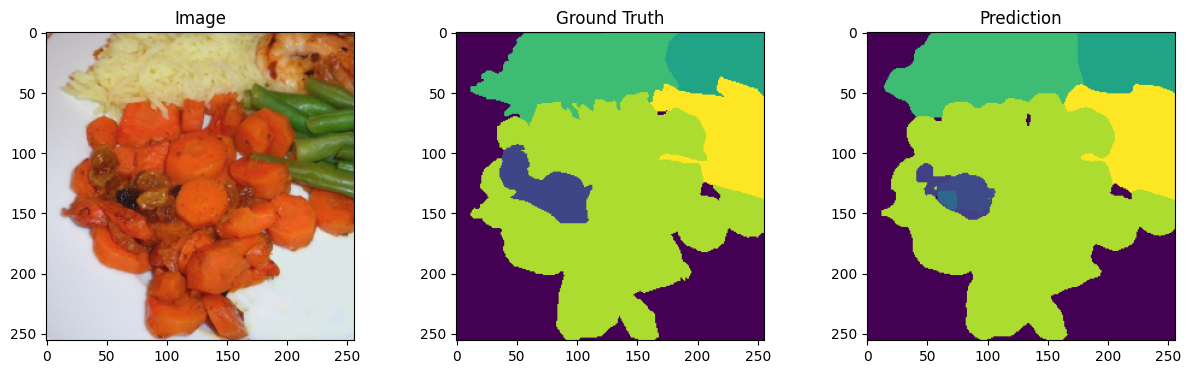

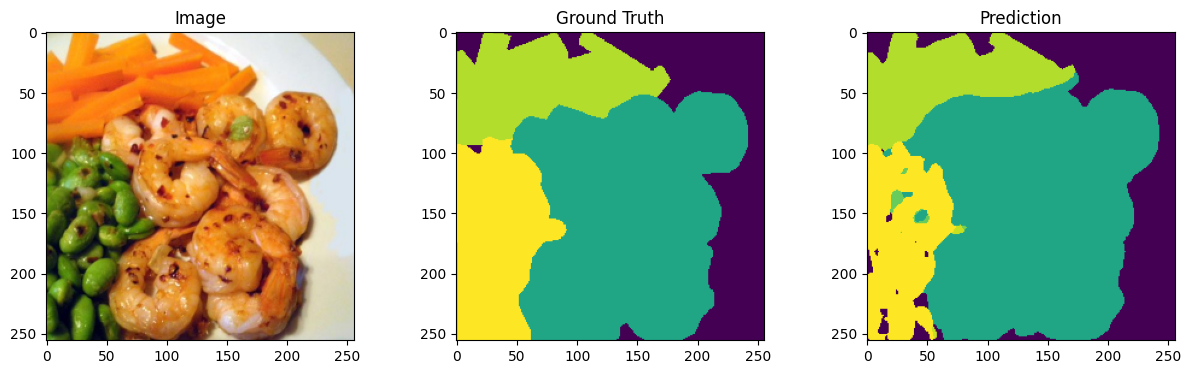

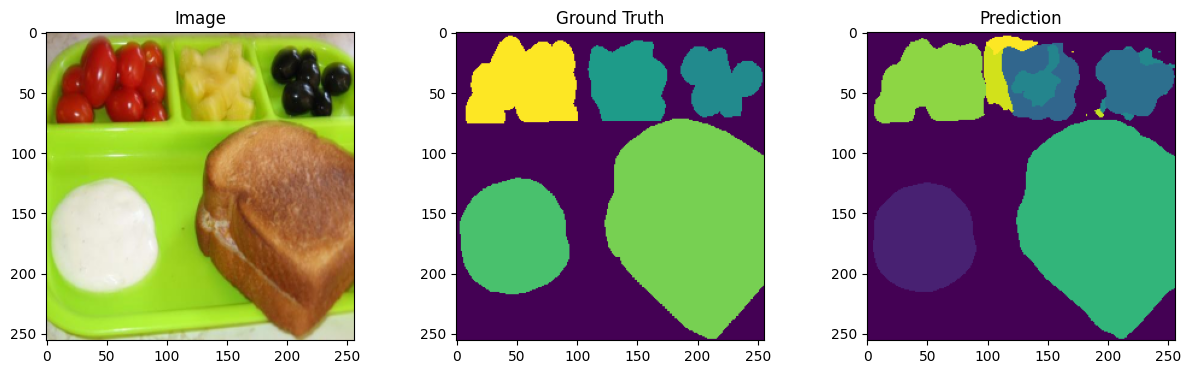

In [ ]:
model.eval()

import matplotlib.pyplot as plt
import numpy as np

for i in range(3):
    image, mask = val_dataset[i]
    image_input = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_input)
        pred_mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()

    plt.figure(figsize=(15,4))

    plt.subplot(1,3,1)
    plt.imshow(image.permute(1,2,0))
    plt.title("Image")

    plt.subplot(1,3,2)
    plt.imshow(mask)
    plt.title("Ground Truth")

    plt.subplot(1,3,3)
    plt.imshow(pred_mask)
    plt.title("Prediction")

    plt.show()

In [ ]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == masks).sum().item()
        total += torch.numel(masks)

print("Pixel Accuracy:", correct / total)

Pixel Accuracy: 0.7163360524233388


In [ ]:
def compute_iou(pred, mask, num_classes=104):
    iou_list = []

    for cls in range(1, num_classes):  # ignore background
        pred_cls = (pred == cls)
        mask_cls = (mask == cls)

        intersection = (pred_cls & mask_cls).sum()
        union = (pred_cls | mask_cls).sum()

        if union == 0:
            continue

        iou = intersection / union
        iou_list.append(iou)

    return np.mean(iou_list) if len(iou_list) > 0 else 0

In [ ]:
iou = compute_iou(pred_mask, mask.numpy())
print("Mean IoU:", iou)

Mean IoU: 0.1804749197367186


In [ ]:
food_groups = {
    "Rice": ["rice", "fried_rice"],
    "Vegetables": ["carrot", "cabbage", "lettuce", "beans", "potato", "tomato", "broccoli"],
    "Meat": ["chicken", "beef", "pork"],
    "Seafood": ["shrimp", "fish"],
    "Nuts": ["walnut", "almond", "peanut"],
    "Fruits": ["apple", "banana", "orange", "blueberry"],
}

In [ ]:
# Build reverse mapping
name_to_group = {}

for group, foods in food_groups.items():
    for food in foods:
        name_to_group[food] = group

In [ ]:
group_calories = {
    "Rice": 130,
    "Vegetables": 50,
    "Meat": 250,
    "Seafood": 200,
    "Nuts": 600,
    "Fruits": 80,
    "Other": 100
}

In [ ]:
def estimate_calories_grouped(image_tensor):
    model.eval()

    image_input = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_input)
        pred_mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()

    unique_classes = np.unique(pred_mask)
    unique_classes = unique_classes[unique_classes != 0]

    pixel_to_gram_ratio = 0.02
    group_mass = {}

    for cls in unique_classes:
        area_pixels = np.sum(pred_mask == cls)
        grams = area_pixels * pixel_to_gram_ratio

        food_name = id_to_name.get(cls, "unknown")
        group = name_to_group.get(food_name, "Other")

        if group not in group_mass:
            group_mass[group] = 0

        group_mass[group] += grams

    total_calories = 0

    print("---- Grouped Calorie Breakdown ----")

    for group, grams in group_mass.items():
        kcal_per_100g = group_calories[group]
        calories = (grams / 100) * kcal_per_100g
        total_calories += calories

        print(f"{group}: {calories:.2f} kcal")

    print("-----------------------------------")
    print("Total Calories:", total_calories)

    # Visualization
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(image_tensor.permute(1,2,0))
    plt.title("Input Image")

    plt.subplot(1,3,2)
    plt.imshow(pred_mask)
    plt.title("Predicted Mask")

    plt.subplot(1,3,3)
    plt.imshow(image_tensor.permute(1,2,0))
    plt.imshow(pred_mask, alpha=0.5)
    plt.title("Overlay")

    plt.show()

    return total_calories

---- Grouped Calorie Breakdown ----
Other: 117.44 kcal
Nuts: 113.16 kcal
Fruits: 3.34 kcal
Seafood: 151.56 kcal
Rice: 221.60 kcal
Vegetables: 279.16 kcal
-----------------------------------
Total Calories: 886.262


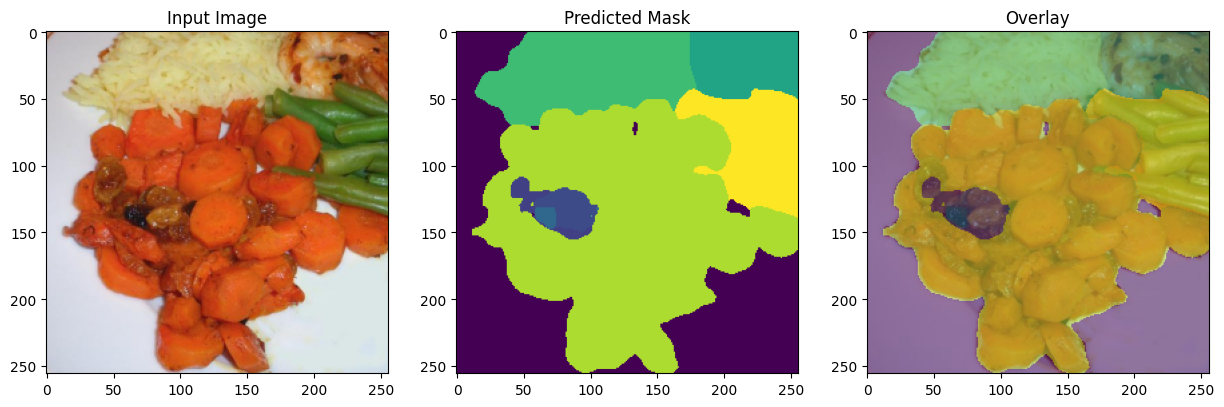

np.float64(886.262)

In [ ]:
image, _ = val_dataset[0]
estimate_calories_grouped(image)

In [ ]:
torch.save(model.state_dict(), "foodseg_final_model.pth")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/foodseg_best_model.pth")
print("Model saved to Google Drive.")

Model saved to Google Drive.
